Importing Libraries

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from pathlib import Path
import os
import random
import warnings

# Notebook settings
%matplotlib inline
warnings.filterwarnings("ignore")



In [2]:
# Define dataset path (adjust based on your environment)
dataset_path = "200 species"  # Example path for Kaggle dataset
test_dir = os.path.join(dataset_path, "test")


In [3]:
# Load class names (species) from test directory
def get_class_names(test_dir):
    class_names = sorted([d for d in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, d))])
    return class_names

class_names = get_class_names(test_dir)
print(f"Number of bird species: {len(class_names)}")


Number of bird species: 200


In [4]:
# Load all test image paths
def load_test_images(test_dir):
    filepaths = []
    labels = []
    for species in class_names:
        species_path = os.path.join(test_dir, species)
        for img in os.listdir(species_path):
            img_path = os.path.join(species_path, img)
            filepaths.append(img_path)
            labels.append(species)
    return pd.DataFrame({"Filepath": filepaths, "Label": labels})

test_df = load_test_images(test_dir)
print(f"Number of test images: {len(test_df)}")

Number of test images: 2374


In [5]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import DepthwiseConv2D

# Define a custom DepthwiseConv2D that ignores 'groups'
class CustomDepthwiseConv2D(DepthwiseConv2D):
    def __init__(self, **kwargs):
        # Remove 'groups' from kwargs if present
        kwargs.pop('groups', None)
        super().__init__(**kwargs)

# Load model with custom objects
model = load_model("best_model_final2.h5", custom_objects={"DepthwiseConv2D": CustomDepthwiseConv2D})
print("Model loaded successfully.")

Model loaded successfully.


In [6]:
# Function to predict bird species for a given image
def predict_image_class(model, img_path, class_names, top_k=5):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = x / 255.0  # Rescale to [0,1]
      # Make prediction
    preds = model.predict(x)
    top_indices = np.argsort(-preds[0])[:top_k]
    top_probs = preds[0][top_indices]
    
    # Return predictions and image for display
    return img, top_indices, top_probs


In [7]:
# Select a random test image
random_idx = random.randint(0, len(test_df) - 1)
random_img_path = test_df["Filepath"].iloc[random_idx]
true_label = test_df["Label"].iloc[random_idx]

# Predict the bird species
img, top_indices, top_probs = predict_image_class(model, random_img_path, class_names)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


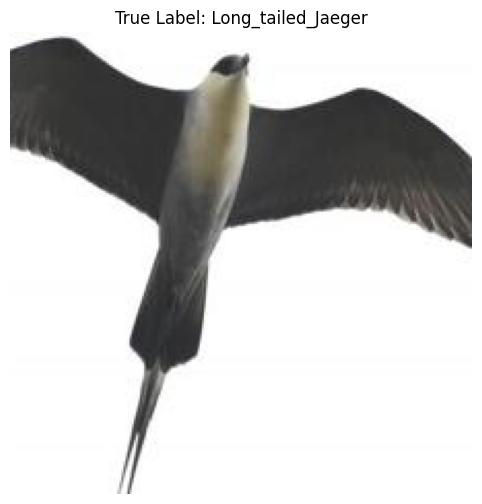


Top 5 Predicted Bird Species:
1. Long_tailed_Jaeger: 56.96% *
2. Frigatebird: 37.74%
3. Yellow_billed_Cuckoo: 1.94%
4. Red_faced_Cormorant: 1.36%
5. Mangrove_Cuckoo: 0.48%
Predicted bird name:Long_tailed_Jaeger


In [8]:
# Display the image and predictions
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.title(f"True Label: {true_label}")
plt.show()

print("\nTop 5 Predicted Bird Species:")
for i, (idx, prob) in enumerate(zip(top_indices, top_probs)):
    label = class_names[idx]
    marker = " *" if label == true_label else ""
    print(f"{i+1}. {label}: {prob*100:.2f}%{marker}")
if class_names[top_indices[0]] == true_label:
    print("Predicted bird name:"+class_names[top_indices[0]])
else:
    print("Prediction: Incorrect (Top-1 mismatch)")